# Deep Hedging


## Libraries, General Settings and Helpers

In [1]:
import time
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
from scipy.special import logsumexp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
def to_tensor(x, dtype=torch.float32, device=device):
    """
    Converts input to a float32 torch tensor on the chosen device.
    """
    if torch.is_tensor(x):
        return x.to(device=device, dtype=dtype)
    return torch.tensor(x, dtype=dtype, device=device)

def to_numpy(x):
    """Convert a Torch tensor to NumPy; leave NumPy arrays unchanged."""
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return x

## Global Variables

In [3]:
# --- Market & Option Parameters ---
S0 = 100.0          # Initial stock price
K = 100.0           # Strike price
r = 0.05            # Risk-free rate
T = 30 / 365        # Time to maturity (e.g., 30 days)
epsilon = 0.005     # Proportional transaction cost (0.5%)

# --- Black-Scholes Parameters ---
sigma = 0.20        # Constant volatility

# --- Heston Model Parameters ---
v0 = 0.04           # Initial variance (e.g., 0.20^2)
kappa = 2.0         # Mean reversion speed
theta = 0.04        # Long-term mean variance
sigma_v = 0.30      # Volatility of variance (vol-of-vol)
rho = -0.70         # Correlation between asset and variance Brownian motions

# --- Simulation Parameters ---
steps = 30          # Number of time steps (e.g., daily hedging)
n_paths_sim = 10000 # Number of paths for baseline/evaluation

# --- Deep Hedging & Training Parameters ---
n_epochs = 1500
batch_size = 256
cvar_alpha = 0.95   # Confidence level for CVaR (95%)
learning_rate = 0.005

# Architecture params (Input: Log-Spot, [Vol for Heston], Prev Delta)
d_bs = 2            # Dimension for Black-Scholes
d_heston = 3        # Dimension for Heston
hidden_dim = [16,16]     # Number of hidden units

# Market Simulation

## Black and Scholes Path Generator

**The Math Behind the Path**

In a discrete-time setting, we update the price at each step $\Delta t$ using the following stochastic differential equation (SDE) solution:
$$S_{t+\Delta t} = S_t \exp\left( (r - \frac{1}{2}\sigma^2)\Delta t + \sigma \sqrt{\Delta t} Z \right)$$
where $Z \sim N(0, 1)$.

In [4]:
def generate_bs_paths(S0, r, sigma, T, steps, n_paths):
    """
    Generates Black-Scholes asset price paths.
    Returns a torch.Tensor of shape (steps + 1, n_paths).
    """
    dt = T / steps

    # Generate all random shocks at once: (steps, n_paths)
    Z = torch.randn(steps, n_paths, device=device)

    # Calculate log returns
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * (dt ** 0.5) * Z
    log_returns = drift + diffusion

    # Add a row of zeros at the start for S0
    zeros = torch.zeros(1, n_paths, device=device)
    cumulative_log_returns = torch.cumsum(torch.cat([zeros, log_returns], dim=0), dim=0)

    paths = S0 * torch.exp(cumulative_log_returns)

    return paths

## Heston Path Generator

### TODO — closer-to-paper Heston simulation

Current implementation uses a practical **full-truncation Euler** scheme with Monte Carlo finite-difference delta.

Later, to get closer to the paper, replace this with:
- **exact sampling of the CIR variance process**
- **simplified Broadie–Kaya scheme** for the Heston price process

The paper’s experiments use exact CIR transition sampling where available, rather than a simple Euler approximation.

The Heston model assumes that the variance of the underlying asset follows its own mean-reverting stochastic process. The dynamics are described by the following system of SDEs:
$$dS_t = r S_t dt + \sqrt{v_t} S_t dW_t^S$$
$$dv_t = \kappa(\theta - v_t)dt + \sigma_v \sqrt{v_t} dW_t^v$$

where the two Wiener processes are correlated such that $dW_t^S dW_t^v = \rho dt$. To simulate this in discrete time, we use an Euler-Maruyama discretization scheme with full truncation to ensure the variance remains positive.

In [7]:
def generate_heston_paths(S0, v0, r, kappa, theta, sigma_v, rho, T, steps, n_paths):
    """
    Generates Heston asset price and variance paths.
    Returns two torch.Tensors of shape (steps + 1, n_paths) for S and v.
    """
    dt = T / steps

    S = torch.zeros(steps + 1, n_paths, device=device)
    v = torch.zeros(steps + 1, n_paths, device=device)

    S[0], v[0] = S0, v0

    for t in range(steps):
        # Correlated Brownian Motions
        Z1 = torch.randn(n_paths, device=device)
        Z2 = torch.randn(n_paths, device=device)
        W_S = Z1
        W_v = rho * Z1 + ((1 - rho**2)**0.5) * Z2

        # Update Variance (using full truncation to ensure v > 0)
        v_prev = torch.clamp(v[t], min=0.0)
        v[t+1] = torch.clamp(v_prev + kappa * (theta - v_prev) * dt + sigma_v * torch.sqrt(v_prev * dt) * W_v, 0)

        # Update Price
        S[t+1] = S[t] * torch.exp((r - 0.5 * v_prev) * dt + torch.sqrt(v_prev * dt) * W_S)

    return S, v

# Hedging

## B-S Delta

For a European Call option, the Black-Scholes delta is given by:
$$\Delta = \Phi(d_1)$$
where:
$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)\tau}{\sigma\sqrt{\tau}}$$
and $\Phi$ is the cumulative distribution function (CDF) of the standard normal distribution. Note that $\tau$ is the time to maturity ($T - t$), which decreases at every step.

In [8]:
def calculate_bs_delta(S, K, r, sigma, tau):
    """
    Calculates the analytical Black-Scholes Delta for a Call option.

    tau: Time remaining to maturity (T - t)
    """
    # Maybe I delete this if i see we always use tensors
    S = to_tensor(S)
    tau = to_tensor(tau)

    eps=1e-6
    tau_clamped = torch.clamp(tau, min=eps)

    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * tau_clamped) / (sigma * torch.sqrt(tau_clamped))
    delta = torch.special.ndtr(d1)

    # At expiration, Delta is 1 if in-the-money, 0 otherwise. To avoid division by 0
    delta = torch.where(tau <= eps, (S > K).float(), delta)

    return delta

## Heston Numerical Delta

### TODO — closer-to-paper Heston benchmark

Current implementation:
- full-truncation Euler for the variance process
- log-Euler update for the stock
- Monte Carlo pricing + central finite-difference delta
- common random numbers + antithetic variates for variance reduction

Closer to the paper:
- exact sampling of the CIR variance transition
- simplified Broadie–Kaya scheme for the Heston stock process

This would make the Heston benchmark more faithful to the original paper, but is a second-step upgrade.

Because the Heston model lacks a straightforward analytical delta, we approximate it using finite differences. We calculate the option price via Monte Carlo simulation with antithetic method at a bumped-up spot price ($S + \epsilon$) and a bumped-down spot price ($S - \epsilon$), then estimate the gradient:
$$\Delta \approx \frac{C(S + \epsilon, v, t) - C(S - \epsilon, v, t)}{2\epsilon}$$

In [9]:
def simulate_heston_from_state(S0, v0, r, kappa, theta, sigma_v, rho, tau,
                               n_paths=1000, sub_steps=20, Z1=None, Z2=None):
    """
    Simulates terminal Heston stock prices from a batch of current states (S0, v0) up to remaining maturity tau.

    Parameters
    ----------
    S0 : tensor-like, shape (B,)
        Current spot values.
    v0 : tensor-like, shape (B,)
        Current variances.
    tau : tensor-like, shape (B,)
        Remaining maturities.
    n_paths : int
        Number of MC paths per state.
    sub_steps : int
        Number of time steps between now and maturity.
    Z1, Z2 : tensors, optional
        Random shocks of shape (sub_steps, B, n_paths).

    Returns
    -------
    S_T : tensor, shape (B, n_paths)
        Simulated terminal stock values for each batch state and MC path.
    """
    S0 = to_tensor(S0).reshape(-1)
    v0 = to_tensor(v0).reshape(-1)
    tau = to_tensor(tau).reshape(-1)

    B = S0.shape[0]

    if Z1 is None or Z2 is None:
        Z1 = torch.randn(sub_steps, B, n_paths, device=device)
        Z2 = torch.randn(sub_steps, B, n_paths, device=device)

    # Each state has its own dt because tau may differ across states
    dt = tau / sub_steps                  # shape: (B,)
    sqrt_dt = torch.sqrt(dt)              # shape: (B,)

    # Expand each state across MC paths
    S_t = S0[:, None].expand(B, n_paths).clone()   # shape: (B, n_paths)
    v_t = v0[:, None].expand(B, n_paths).clone()   # shape: (B, n_paths)

    rho_t = torch.as_tensor(rho, device=device, dtype=S_t.dtype)
    sqrt_1_minus_rho2 = torch.sqrt(torch.clamp(1.0 - rho_t**2, min=0.0))

    for j in range(sub_steps):
        z1 = Z1[j]    # shape: (B, n_paths)
        z2 = Z2[j]    # shape: (B, n_paths)

        # Correlated shock for variance process
        z_v = rho_t * z1 + sqrt_1_minus_rho2 * z2

        dt_j = dt[:, None]           # shape: (B, 1)
        sqrt_dt_j = sqrt_dt[:, None] # shape: (B, 1)

        v_pos = torch.clamp(v_t, min=0.0)

        # Full truncation Euler for variance
        v_next = (v_t + kappa * (theta - v_pos) * dt_j + sigma_v * torch.sqrt(v_pos) * sqrt_dt_j * z_v)
        v_next = torch.clamp(v_next, min=0.0)

        # Stock update
        S_t = S_t * torch.exp((r - 0.5 * v_pos) * dt_j + torch.sqrt(v_pos) * sqrt_dt_j * z1)

        v_t = v_next

    return S_t

#=====================================================================================

def heston_price_mc(S, v, K, r, kappa, theta, sigma_v, rho, tau,
                    n_mc=1000, sub_steps=20, Z1=None, Z2=None,
                    return_stats=False):
    """
    Batched Heston call pricing by Monte Carlo from current states.

    Parameters
    ----------
    S : tensor-like, shape (B,)
        Current spot values.
    v : tensor-like, shape (B,)
        Current variances.
    tau : tensor-like, shape (B,)
        Remaining maturities.
    K, r, kappa, theta, sigma_v, rho : scalars
        Option/model parameters.
    n_mc : int
        Number of MC paths per state.
    sub_steps : int
        Number of simulation substeps.
    Z1, Z2 : tensors, optional
        Random shocks of shape (sub_steps, B, n_mc).
    return_stats : bool
        If True, also return std of discounted payoffs and MC std error.

    Returns
    -------
    price : tensor, shape (B,)
    std_payoff : tensor, shape (B,)      [if return_stats=True]
    std_error : tensor, shape (B,)       [if return_stats=True]
    """
    S = to_tensor(S).reshape(-1)
    v = to_tensor(v).reshape(-1)
    tau = to_tensor(tau).reshape(-1)

    B = S.shape[0]

    price = torch.zeros_like(S)

    if return_stats:
        std_payoff_out = torch.zeros_like(S)
        std_error_out = torch.zeros_like(S)

    # Mask for non-expired states
    alive = tau > 1e-6

    # Expired states: option value = payoff
    if (~alive).any():
        price[~alive] = torch.clamp(S[~alive] - K, min=0.0)

        if return_stats:
            std_payoff_out[~alive] = 0.0
            std_error_out[~alive] = 0.0

    # Live states: run MC for the non expired options/states
    if alive.any():
        S_live = S[alive]         # shape: (B_live,)
        v_live = v[alive]
        tau_live = tau[alive]
        B_live = S_live.shape[0]

        S_T = simulate_heston_from_state(S0=S_live, v0=v_live, r=r, kappa=kappa, 
                                         theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_live,
                                         n_paths=n_mc, sub_steps=sub_steps, Z1=Z1, Z2=Z2)  # shape: (B_live, n_mc)

        payoff = torch.clamp(S_T - K, min=0.0)                     # (B_live, n_mc)
        discounted_payoff = torch.exp(-r * tau_live)[:, None] * payoff
        price_live = discounted_payoff.mean(dim=1)                 # (B_live,)

        price[alive] = price_live

        if return_stats:
            std_payoff_live = discounted_payoff.std(dim=1, unbiased=True)
            std_error_live = std_payoff_live / torch.sqrt(torch.tensor(n_mc, device=device, dtype=discounted_payoff.dtype))

            std_payoff_out[alive] = std_payoff_live
            std_error_out[alive] = std_error_live

    if return_stats:
        return price, std_payoff_out, std_error_out

    return price

#=========================================================================================

def calculate_heston_delta(S, v, K, r, kappa, theta, sigma_v, rho, tau,
                           n_mc=2000, sub_steps=20, bump_ratio=0.01, chunk_size=None):
    """
    Batched Heston delta via central finite differences.
    Uses common random numbers, antithetic variates, and optional chunking.
    """
    S = to_tensor(S).reshape(-1)
    v = to_tensor(v).reshape(-1)
    tau = to_tensor(tau).reshape(-1)

    B = S.shape[0]

    if chunk_size is not None and chunk_size < B:
        parts = []
        for start in range(0, B, chunk_size):
            end = min(start + chunk_size, B)
            delta_chunk = calculate_heston_delta(S=S[start:end], v=v[start:end], K=K, r=r,
                                                 kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho, tau=tau[start:end],
                                                 n_mc=n_mc, sub_steps=sub_steps, bump_ratio=bump_ratio,
                                                 chunk_size=None) # None break recursion
            parts.append(delta_chunk)
        return torch.cat(parts, dim=0)

    delta = torch.zeros_like(S)

    alive = tau > 1e-6

    if (~alive).any():
        delta[~alive] = (S[~alive] > K).float()

    if not alive.any():
        return delta

    S_live = S[alive]
    v_live = v[alive]
    tau_live = tau[alive]

    epsilon = torch.clamp(bump_ratio * S_live, min=1e-4)

    B_live = S_live.shape[0]
    half_mc = n_mc // 2

    Z1_half = torch.randn(sub_steps, B_live, half_mc, device=device)
    Z2_half = torch.randn(sub_steps, B_live, half_mc, device=device)

    Z1 = torch.cat([Z1_half, -Z1_half], dim=2)
    Z2 = torch.cat([Z2_half, -Z2_half], dim=2)

    price_up = heston_price_mc(S=S_live + epsilon, v=v_live, K=K, r=r, kappa=kappa,
                               theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_live,
                               n_mc=n_mc, sub_steps=sub_steps, Z1=Z1, Z2=Z2,
                               return_stats=False)

    price_down = heston_price_mc(S=S_live - epsilon, v=v_live, K=K, r=r, kappa=kappa,
                                 theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_live,
                                 n_mc=n_mc, sub_steps=sub_steps, Z1=Z1, Z2=Z2,
                                 return_stats=False)

    delta_live = (price_up - price_down) / (2.0 * epsilon)
    delta[alive] = delta_live

    return delta

## Baseline Simulation Runner

To evaluate our Deep Hedging model, we need a baseline to compare it against. These functions calculate the hedging PnL across all our simulated paths using the traditional analytical (Black-Scholes) or numerical (Heston) deltas. We also factor in the proportional transaction costs ($\epsilon$) to reflect real-world trading friction.

In [10]:
def run_bs_baseline(paths, K, r, sigma, T, epsilon, premium=0.0):
    """
    Computes the baseline hedging PnL using analytical Black-Scholes Delta.

    --------
    premium : initial price of the option, positive if seller and negative if buyer
    esplion : proportional transaction cost
    paths   : torch.Tensor of shape (steps + 1, n_paths)
    """
    # Convert to numpy for the analytical function
    paths = to_tensor(paths)

    n_steps, n_paths = paths.shape[0] - 1, paths.shape[1]
    dt = T / n_steps

    deltas = torch.zeros(n_steps, n_paths, device=device)

    for t_idx in range(n_steps):
        tau = T - (t_idx * dt)
        # Vectorized calculation across all paths at time t
        deltas[t_idx] = calculate_bs_delta(paths[t_idx], K, r, sigma, tau)

    # 1. Hedging Gains
    price_changes = paths[1:] - paths[:-1]
    hedging_gains = torch.sum(deltas * price_changes, dim=0)

    # 2. Transaction Costs
    initial_cost = epsilon * paths[0] * torch.abs(deltas[0])
    diff_deltas = torch.abs(deltas[1:] - deltas[:-1])
    running_costs = torch.sum(epsilon * paths[1:-1] * diff_deltas, dim=0)
    total_costs = initial_cost + running_costs

    # 3. Payoff and Final PnL
    payoff = torch.clamp(paths[-1] - K, min=0.0)
    pnl = premium + hedging_gains - total_costs - payoff

    return deltas, pnl

#=========================================================================================
# Maybe i need to change premium which in theory is the price
def run_heston_baseline(paths, vol_paths, K, r, kappa, theta, sigma_v, rho, T,
                        epsilon, premium=0.0, chunk_size=None,
                        n_mc=2000, sub_steps=20, bump_ratio=0.01):
    """
    Compute seller-side baseline hedging PnL under Heston using
    batched finite-difference delta hedging with proportional costs.
    """
    paths = to_tensor(paths)
    vol_paths = to_tensor(vol_paths)

    n_steps = paths.shape[0] - 1
    n_paths = paths.shape[1]
    dt = T / n_steps

    deltas = torch.zeros(n_steps, n_paths, device=device)

    # Batched delta computation: one call per hedge date
    for t_idx in range(n_steps):
        tau_t = torch.full((n_paths,), T - t_idx * dt, device=device, dtype=paths.dtype)

        deltas[t_idx] = calculate_heston_delta(S=paths[t_idx], v=vol_paths[t_idx], K=K, r=r,
                                               kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_t,
                                               n_mc=n_mc, sub_steps=sub_steps, bump_ratio=bump_ratio, chunk_size=chunk_size)

    # 1) Hedging gains
    price_changes = paths[1:] - paths[:-1]                  # (n_steps, n_paths)
    hedging_gains = torch.sum(deltas * price_changes, dim=0)

    # 2) Transaction costs
    initial_cost = epsilon * paths[0] * torch.abs(deltas[0])

    if n_steps > 1:
        diff_deltas = torch.abs(deltas[1:] - deltas[:-1])   # (n_steps-1, n_paths)
        running_costs = torch.sum(epsilon * paths[1:-1] * diff_deltas, dim=0)
    else:
        running_costs = torch.zeros(n_paths, device=device, dtype=paths.dtype)

    total_costs = initial_cost + running_costs

    # 3) Payoff and final seller-side PnL
    payoff = torch.clamp(paths[-1] - K, min=0.0)
    pnl = premium + hedging_gains - total_costs - payoff

    return deltas, pnl

# Architecture

## Network Definition

For each time step $k$, we use a shared-weight feedforward neural network $F_{\theta}$ to determine our hedge ratio.

* **Inputs ($I_k$):** The normalized market features. For Black-Scholes, we use the Log-Spot price ($\ln(S_t/S_0)$) and the previous delta ($\delta_{t-1}$). For Heston, we also append the current variance ($v_t$).
* **Hidden Layers:** 2 hidden layers using ReLU activation and Batch Normalization.
* **Output:** A single linear value representing the new position ($\delta_t$).

In [ ]:
class DeepHedgeNet(nn.Module):
    def __init__(self, input_dim, hidden_dims = [16, 16]):
        """
        Feedforward Neural Network for Deep Hedging.
        """
        super().__init__()

        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))

        self.layers = nn.Sequential(*layers)

        # Xavier Initialization for better convergence
        for m in self.layers:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def forward(self, x):
        return self.layers(x).squeeze(-1)
    
# Note:
# - putting layers.append(nn.BatchNorm1d(h)) lower NN performance

## P&L with Transaction Costs

To evaluate a hedging strategy, we calculate the terminal Profit and Loss (PnL). For a short call option position being hedged, the PnL is defined as:
$$\text{PnL} = \text{Hedging Gains} - \text{Transaction Costs} - \text{Option Payoff}$$

We define the transaction cost at each time step $t$ as proportional to the trade size and current spot price:
$$Cost_t = \epsilon \cdot S_t \cdot |\delta_t - \delta_{t-1}|$$

where $\epsilon$ is the cost rate (e.g., $0.005$ for 0.5%). We must also account for the initial cost of entering the hedge: $\epsilon \cdot S_0 \cdot |\delta_0|$.

In [12]:
def get_pnl(paths, deltas, K, epsilon, premium=0.0):
    """
    Calculates the terminal PnL for a batch of simulated paths.

    paths: torch.Tensor of shape (steps + 1, n_paths)
    deltas: torch.Tensor of shape (steps, n_paths)
    K: Strike price
    epsilon: Proportional transaction cost
    """
    # 1. Hedging Gains (sum of delta * price change)
    price_changes = paths[1:] - paths[:-1]
    hedging_gains = torch.sum(deltas * price_changes, dim=0)

    # 2. Transaction Costs
    # Initial trade to set up the hedge at t=0
    initial_cost = epsilon * paths[0] * torch.abs(deltas[0])

    # Subsequent rebalancing trades
    diff_deltas = torch.abs(deltas[1:] - deltas[:-1])
    running_costs = torch.sum(epsilon * paths[1:-1] * diff_deltas, dim=0)

    total_costs = initial_cost + running_costs

    # 3. Terminal Payoff (Short Call)
    payoff = torch.relu(paths[-1] - K)

    # 4. Final Terminal PnL
    return premium + hedging_gains - total_costs - payoff

## CVaR Loss Function

To make CVaR differentiable for backpropagation, we use the Rockafellar-Uryasev formula:
$$\text{CVaR}_\alpha(L) = \min_{v} \left\{ v + \frac{1}{1-\alpha} \mathbb{E}[\max(0, L - v)] \right\}$$

where:
* $L$ is our loss (defined as negative PnL: $-PnL$).
* $v$ is a trainable parameter that converges to the Value at Risk ($\text{VaR}_\alpha$).
* $\alpha$ is our confidence level (e.g., 0.95 or 95%).

In [13]:
def cvar_loss(pnl, alpha, v_param):
    """
    Calculates the Conditional Value at Risk (Expected Shortfall).

    pnl: Tensor of terminal PnL
    alpha: Confidence level (e.g., 0.95)
    v_param: Learnable VaR threshold parameter (torch.nn.Parameter)
    """
    # Invert PnL to represent Loss (since PyTorch optimizers minimize the objective)
    losses = -pnl

    # Calculate the tail loss: max(0, Loss - VaR)
    tail_loss = torch.clamp(losses - v_param, min=0)

    # Return the Rockafellar-Uryasev objective
    return v_param + (1 / (1 - alpha)) * torch.mean(tail_loss)

## Entropic Risk Measure

For a position $X$ and a risk-aversion parameter $\lambda > 0$, the measure is defined as:
$$\rho(X) = \frac{1}{\lambda} \log \mathbb{E}[\exp(-\lambda X)]$$

where:
* $X$ is our terminal Profit and Loss (PnL).
* $\lambda$ is the risk-aversion parameter (higher values mean the network will penalize variance more heavily).

In [14]:
def entropic_loss(pnl, lambda_param=1.0):
    """
    Calculates the Entropic Risk Measure.
    Numerically stable implementation to prevent float32 overflow.
    """
    # x = -lambda * PnL
    x = -lambda_param * pnl

    # Mathematically: log(mean(exp(x))) == logsumexp(x) - log(N)
    N = x.shape[0]

    # torch.logsumexp safely handles extremely large exponents
    log_mean_exp = torch.logsumexp(x, dim=0) - torch.log(torch.tensor(N, dtype=x.dtype, device=x.device))

    return (1.0 / lambda_param) * log_mean_exp

# Training & Evaluation

## Training Loop

This is our main Deep Hedging training pipeline. It generates fresh market paths for every batch to prevent overfitting (on-policy reinforcement learning). For each time step, the model observes the market state (Log-Spot price, previous Delta, and optionally Variance for the Heston model) and outputs a new hedge ratio.

The optimizer updates both the neural network weights $\theta$ and the Value-at-Risk threshold $v$ simultaneously to minimize the CVaR of our hedging PnL.

In [15]:
def train_model(env_type, S0, K, r, T, steps, epsilon, premium=0.0,
                hidden_dims = [16,16], batch_size=256, n_epochs=500, lr=0.005,
                loss_type='cvar', alpha=0.95, lambda_param=1.0, **env_params):
    """
    Trains the Deep Hedging model.
    loss_type: 'cvar' or 'entropic'
    """
    # 1. Setup Architecture
    input_dim = 4 if env_type == 'heston' else 3
    model = DeepHedgeNet(input_dim=input_dim, hidden_dims=hidden_dims).to(device)

    # 2. Setup Optimizer based on Loss Type
    if loss_type == 'cvar':
        v_var = nn.Parameter(torch.tensor(0.0, requires_grad=True, device=device))
        optimizer = torch.optim.Adam(list(model.parameters()) + [v_var], lr=lr)
    elif loss_type == 'entropic':
        v_var = None # Not needed for Entropic Risk
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("loss_type must be 'cvar' or 'entropic'")

    loss_history = []
    start_time = time.time()
    pbar = tqdm(range(n_epochs), desc=f"Training {env_type.upper()} ({loss_type.upper()})")

    for epoch in pbar:
        model.train()
        optimizer.zero_grad()

        # 3. Generate fresh paths
        if env_type == 'heston':
            paths, vols = generate_heston_paths(S0=S0, v0=env_params['v0'], r=r,
                                                kappa=env_params['kappa'], theta=env_params['theta'], sigma_v=env_params['sigma_v'],
                                                rho=env_params['rho'], T=T,
                                                n_steps=steps, n_paths=batch_size)
        else:
            paths = generate_bs_paths(S0=S0, r=r, sigma=env_params['sigma'], T=T,
                                      steps=steps, n_paths=batch_size)

        # 4. Forward pass through time
        all_deltas = []
        prev_delta = torch.zeros(batch_size, device=device, dtype=paths.dtype)

        for t in range(steps):
            log_spot = torch.log(paths[t] / S0).unsqueeze(1)
            tau_t = torch.full((batch_size, 1), T - t * (T / steps), device=device, dtype=paths.dtype)

            prev_delta_col = prev_delta.unsqueeze(1)  # (batch, 1)
            if env_type == 'heston':
                vol_current = vols[t].unsqueeze(1)
                x = torch.cat([log_spot, vol_current, tau_t, prev_delta_col], dim=1)
            else:
                x = torch.cat([log_spot, tau_t, prev_delta_col], dim=1)

            curr_delta = model(x)
            all_deltas.append(curr_delta)
            prev_delta = curr_delta

        deltas = torch.stack(all_deltas, dim=0)

        # 5. Compute PnL
        pnl = get_pnl(paths, deltas, K, epsilon, premium = premium)

        # 6. Calculate Target Loss
        if loss_type == 'cvar':
            loss = cvar_loss(pnl, alpha, v_var)
        else:
            loss = entropic_loss(pnl, lambda_param)

        # 7. Backpropagation
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        loss_history.append(loss_value)

        if loss_type == 'cvar':
            pbar.set_postfix(loss=f"{loss_value:.4f}", v=f"{v_var.item():.4f}")
        else:
            pbar.set_postfix(loss=f"{loss_value:.4f}")

    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed:.2f} seconds.")

    return {"model": model,
            "v_var": v_var.item() if v_var is not None else None,
            "loss_history": loss_history,
            "final_loss": loss_history[-1]}

## Evaluation Metrics

Once the model is trained, we need to test it on a large, unseen dataset to evaluate its true performance. The evaluation function computes the Deep Hedging deltas across these test paths and calculates key risk metrics on the resulting P&L distribution.

* **Mean & Std**: The average profit/loss and its volatility.
* **VaR (95%)**: The maximum loss at the 95% confidence level.
* **CVaR (95%)**: The expected loss *given* that the loss has exceeded the VaR threshold.
* **Turnover**: The average absolute sum of position changes (shows how aggressively the network trades).

In [16]:
def evaluate_model(model, env_type, test_paths, K, epsilon, S0, T, premium = 0.0, test_vols=None):
    """
    Evaluates the trained Deep Hedge network on out-of-sample test paths.
    """
    model.eval()

    test_paths = to_tensor(test_paths)
    if test_vols is not None:
        test_vols = to_tensor(test_vols)

    steps = test_paths.shape[0] - 1
    dt = T / steps   
    n_paths = test_paths.shape[1]

    all_deltas = []
    prev_delta = torch.zeros(n_paths, device=device, dtype=test_paths.dtype)

    # Disable gradient computation for faster inference
    with torch.no_grad():
        for t in range(steps):
            log_spot = torch.log(test_paths[t] / S0).unsqueeze(1)
            tau_t = torch.full((n_paths, 1), T - t * dt, device=device, dtype=test_paths.dtype)
            prev_delta_col = prev_delta.unsqueeze(1)

            if env_type == 'heston' and test_vols is not None:
                if test_vols is None:
                    raise ValueError("test_vols must be provided for env_type='heston'")
                vol_current = test_vols[t].unsqueeze(1)
                x = torch.cat([log_spot, vol_current, tau_t, prev_delta_col], dim=1)
            else:
                x = torch.cat([log_spot, tau_t, prev_delta_col], dim=1)

            curr_delta = model(x)
            all_deltas.append(curr_delta)
            prev_delta = curr_delta

    deltas = torch.stack(all_deltas, dim=0)
    pnl = get_pnl(test_paths, deltas, K, epsilon, premium=premium)

    # Calculate Risk Metrics
    # Note: VaR and CVaR are typically reported as positive numbers for losses
    losses = -pnl
    var_95 = torch.quantile(losses, 0.95)

    # Only average the losses that are strictly greater than the VaR threshold
    tail_losses = losses[losses >= var_95]
    cvar_95 = tail_losses.mean() if tail_losses.numel() > 0 else var_95

    # Turnover: sum of absolute changes in delta
    turnover = torch.mean(torch.sum(torch.abs(deltas[1:] - deltas[:-1]), dim=0))

    metrics = {"Mean PnL": pnl.mean().item(),
               "Std PnL": pnl.std(unbiased=False).item(),
               "VaR (95%)": var_95.item(),
               "CVaR (95%)": cvar_95.item(),
               "Turnover": turnover.item()}

    pnl = to_numpy(pnl)
    deltas= to_numpy(deltas)

    return metrics, pnl, deltas

# Experiment

## B-S without transaction costs

As a baseline sanity check, we first train and evaluate the model in a Black-Scholes environment with zero transaction costs ($\epsilon = 0$). In this frictionless setup, the optimal strategy mathematically proven to minimize variance is the analytical Black-Scholes Delta. Our neural network should naturally converge to this exact strategy.

In [17]:
print("--- Generating Test Set ---")
test_paths_bs = generate_bs_paths(S0, r, sigma, T, steps, n_paths_sim)

# 1. Run Analytical Baseline
print("Running Analytical Black-Scholes Baseline...")
bs_deltas_0, bs_pnl_0 = run_bs_baseline(test_paths_bs, K, r, sigma, T, epsilon=0.0)
bs_deltas_0, bs_pnl_0 = to_numpy(bs_deltas_0), to_numpy(bs_pnl_0) 

# Calculate baseline metrics manually for comparison
bs_losses_0 = -bs_pnl_0
bs_var_95_0 = np.percentile(bs_losses_0, 95)
bs_cvar_95_0 = np.mean(bs_losses_0[bs_losses_0 >= bs_var_95_0])
bs_turnover_0 = np.mean(np.sum(np.abs(np.diff(bs_deltas_0, axis=0)), axis=0))

print(f"Baseline CVaR (95%): {bs_cvar_95_0:.4f}")

# 2. Train Deep Hedging Model
print("\n--- Training Deep Hedging Model (eps = 0.0) ---")
# Pass sigma via kwargs for the BS environment
train_out_bs_0 = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                             epsilon=0.0, batch_size=batch_size, n_epochs=n_epochs,
                             sigma=sigma)
model_bs_0 = train_out_bs_0["model"]

# 3. Evaluate Deep Hedging Model
print("\n--- Evaluating Deep Hedging Model ---")
metrics_bs_0, dh_pnl_0, dh_deltas_0 = evaluate_model(model_bs_0, 'bs', test_paths_bs, K, epsilon=0.0, S0=S0, T=T)

# 4. Compare Results
print("\n=== RESULTS COMPARISON (NO COSTS) ===")
print(f"{'Metric':<15} | {'Analytical BS':<15} | {'Deep Hedging':<15}")
print("-" * 50)
print(f"{'Mean PnL':<15} | {np.mean(bs_pnl_0):>15.4f} | {metrics_bs_0['Mean PnL']:>15.4f}")
print(f"{'Std PnL':<15} | {np.std(bs_pnl_0):>15.4f} | {metrics_bs_0['Std PnL']:>15.4f}")
print(f"{'VaR (95%)':<15} | {bs_var_95_0:>15.4f} | {metrics_bs_0['VaR (95%)']:>15.4f}")
print(f"{'CVaR (95%)':<15} | {bs_cvar_95_0:>15.4f} | {metrics_bs_0['CVaR (95%)']:>15.4f}")
print(f"{'Turnover':<15} | {bs_turnover_0:>15.4f} | {metrics_bs_0['Turnover']:>15.4f}")

--- Generating Test Set ---
Running Analytical Black-Scholes Baseline...
Baseline CVaR (95%): 3.1339

--- Training Deep Hedging Model (eps = 0.0) ---


Training BS (CVAR):   0%|          | 0/1500 [00:00<?, ?it/s]

Training completed in 18.74 seconds.

--- Evaluating Deep Hedging Model ---

=== RESULTS COMPARISON (NO COSTS) ===
Metric          | Analytical BS   | Deep Hedging   
--------------------------------------------------
Mean PnL        |         -2.2873 |         -2.2888
Std PnL         |          0.3715 |          0.4590
VaR (95%)       |          2.9032 |          2.9455
CVaR (95%)      |          3.1339 |          3.1294
Turnover        |          1.7096 |          1.5884


## B-S with transaction costs

Now we introduce market friction by setting our transaction cost rate to 0.5%. The traditional Black-Scholes delta ignores these costs and will over-trade, racking up huge fees. Our Deep Hedging model, trained with these costs included in its PnL function, should learn to trade less aggressively, resulting in a significantly lower Turnover and a better overall CVaR.

In [20]:
print("--- Running Analytical Baseline (eps = 0.005) ---")
# We reuse the test_paths_bs from Experiment 1 for a fair comparison
bs_deltas_cost, bs_pnl_cost = run_bs_baseline(test_paths_bs, K, r, sigma, T, epsilon=epsilon)
bs_deltas_cost, bs_pnl_cost = to_numpy(bs_deltas_cost), to_numpy(bs_pnl_cost) 

# Calculate baseline metrics
bs_losses_cost = -bs_pnl_cost
bs_var_95_cost = np.percentile(bs_losses_cost, 95)
bs_cvar_95_cost = np.mean(bs_losses_cost[bs_losses_cost > bs_var_95_cost])
bs_turnover_cost = np.mean(np.sum(np.abs(np.diff(bs_deltas_cost, axis=0)), axis=0))

# Train Deep Hedging Model
print("\n--- Training Deep Hedging Model (eps = 0.005) ---")
train_out_bs_cost = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                                epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
                                sigma=sigma)
model_bs_cost = train_out_bs_0["model"]

# Evaluate Deep Hedging Model
print("\n--- Evaluating Deep Hedging Model ---")
metrics_bs_cost, dh_pnl_cost, dh_deltas_cost = evaluate_model(model_bs_cost, 'bs', test_paths_bs, K, epsilon=epsilon, S0=S0, T=T)

# Compare Results
print("\n=== RESULTS COMPARISON (WITH 0.5% COSTS) ===")
print(f"{'Metric':<15} | {'Analytical BS':<15} | {'Deep Hedging':<15}")
print("-" * 50)
print(f"{'Mean PnL':<15} | {np.mean(bs_pnl_cost):>15.4f} | {metrics_bs_cost['Mean PnL']:>15.4f}")
print(f"{'Std PnL':<15} | {np.std(bs_pnl_cost):>15.4f} | {metrics_bs_cost['Std PnL']:>15.4f}")
print(f"{'VaR (95%)':<15} | {bs_var_95_cost:>15.4f} | {metrics_bs_cost['VaR (95%)']:>15.4f}")
print(f"{'CVaR (95%)':<15} | {bs_cvar_95_cost:>15.4f} | {metrics_bs_cost['CVaR (95%)']:>15.4f}")
print(f"{'Turnover':<15} | {bs_turnover_cost:>15.4f} | {metrics_bs_cost['Turnover']:>15.4f}")

--- Running Analytical Baseline (eps = 0.005) ---

--- Training Deep Hedging Model (eps = 0.005) ---


Training BS (CVAR):   0%|          | 0/1500 [00:00<?, ?it/s]

Training completed in 18.79 seconds.

--- Evaluating Deep Hedging Model ---

=== RESULTS COMPARISON (WITH 0.5% COSTS) ===
Metric          | Analytical BS   | Deep Hedging   
--------------------------------------------------
Mean PnL        |         -3.4118 |         -3.3467
Std PnL         |          0.5183 |          0.5006
VaR (95%)       |          4.3834 |          4.1560
CVaR (95%)      |          4.7009 |          4.4198
Turnover        |          1.7096 |          1.5884


## Heston with transaction costs

Our final experiment tests the deep hedging framework in a much more complex environment: the Heston model. Here, volatility is no longer constant but follows its own stochastic process. The baseline relies on a computationally heavy finite-difference Monte Carlo approach.

Our Deep Hedging network takes three inputs at each step ($I_k$): the log-spot price, the current variance, and the previous position. It learns to balance the risks of both the asset's price movements and the volatility surface changes, all while navigating transaction costs.

In [ ]:
train_out_bs_cost = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                                epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
                                sigma=sigma)
model_bs_cost = train_out_bs_0["model"]

In [ ]:
print("--- Generating Heston Test Set ---")
test_paths_h, test_vols_h = generate_heston_paths(S0, v0, r, kappa, theta, sigma_v, rho, T, steps, n_paths_sim)

# 1. Run Baseline 
print("Running Numerical Heston Baseline")
h_deltas_base, h_pnl_base = run_heston_baseline(test_paths_h, test_vols_h, K, r, kappa, theta, sigma_v, rho, T, epsilon=epsilon)
h_deltas_base, h_pnl_base = to_numpy(h_deltas_base), to_numpy(h_pnl_base) 

# Calculate baseline metrics
h_losses_base = -h_pnl_base
h_var_95_base = np.percentile(h_losses_base, 95)
h_cvar_95_base = np.mean(h_losses_base[h_losses_base > h_var_95_base])
h_turnover_base = np.mean(np.sum(np.abs(np.diff(h_deltas_base, axis=0)), axis=0))

# 2. Train Deep Hedging Model
print("\n--- Training Deep Hedging Model (Heston) ---")
train_out_h_base = train_model(env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
                                 epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
                                 v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho)
model_h_base = train_out_h_base["model"]

# 3. Evaluate Deep Hedging Model
print("\n--- Evaluating Deep Hedging Model ---")
metrics_h, dh_pnl_h, dh_deltas_h = evaluate_model(model_h_base, 'heston', test_paths_h, K, epsilon=epsilon, S0=S0, test_vols=test_vols_h, T=T)

# 4. Compare Results
print("\n=== RESULTS COMPARISON (HESTON WITH COSTS) ===")
print(f"{'Metric':<15} | {'Numerical Heston':<18} | {'Deep Hedging':<15}")
print("-" * 55)
print(f"{'Mean PnL':<15} | {np.mean(h_pnl_base):>18.4f} | {metrics_h['Mean PnL']:>15.4f}")
print(f"{'Std PnL':<15} | {np.std(h_pnl_base):>18.4f} | {metrics_h['Std PnL']:>15.4f}")
print(f"{'VaR (95%)':<15} | {h_var_95_base:>18.4f} | {metrics_h['VaR (95%)']:>15.4f}")
print(f"{'CVaR (95%)':<15} | {h_cvar_95_base:>18.4f} | {metrics_h['CVaR (95%)']:>15.4f}")
print(f"{'Turnover':<15} | {h_turnover_base:>18.4f} | {metrics_h['Turnover']:>15.4f}")

--- Generating Heston Test Set ---
Running Numerical Heston Baseline (Grab a coffee, this takes a bit)...


KeyboardInterrupt: 

## B-S with Entropic Risk Measure

In this experiment, we switch our loss function from CVaR to the Entropic Risk Measure ($\lambda = 1.0$) under proportional transaction costs ($\epsilon = 0.005$).

This exactly replicates the objective function used by the authors to calculate the exponential utility indifference price.

We expect the network to find a strategy that balances variance reduction with transaction cost savings.

In [ ]:
print("--- Training Deep Hedging Model (Entropic Loss, eps = 0.005) ---")

# 1. Train the model using the new loss_type
model_bs_entropic, final_loss = train_model(
    env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
    epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
    sigma=sigma,
    loss_type='entropic', # Toggle the switch to Entropic
    lambda_param=1.0      # Set risk aversion
)

# 2. Evaluate the Entropic Model
print("\n--- Evaluating Entropic Deep Hedging Model ---")
# We reuse test_paths_bs generated back in Experiment 1
metrics_bs_entropic, entropic_pnl, entropic_deltas = evaluate_model(
    model_bs_entropic, 'bs', test_paths_bs, K, epsilon=epsilon, S0=S0
)

# 3. Compare Results against the Baseline (bs_pnl_cost) and CVaR model (metrics_bs_cost)
print("\n=== RESULTS COMPARISON (0.5% COSTS) ===")
print(f"{'Metric':<15} | {'Analytical BS':<15} | {'Deep Hedge (CVaR)':<18} | {'Deep Hedge (Entropic)':<20}")
print("-" * 75)
print(f"{'Mean PnL':<15} | {np.mean(bs_pnl_cost):>15.4f} | {metrics_bs_cost['Mean PnL']:>18.4f} | {metrics_bs_entropic['Mean PnL']:>20.4f}")
print(f"{'Std PnL':<15} | {np.std(bs_pnl_cost):>15.4f} | {metrics_bs_cost['Std PnL']:>18.4f} | {metrics_bs_entropic['Std PnL']:>20.4f}")
print(f"{'VaR (95%)':<15} | {bs_var_95_cost:>15.4f} | {metrics_bs_cost['VaR (95%)']:>18.4f} | {metrics_bs_entropic['VaR (95%)']:>20.4f}")
print(f"{'CVaR (95%)':<15} | {bs_cvar_95_cost:>15.4f} | {metrics_bs_cost['CVaR (95%)']:>18.4f} | {metrics_bs_entropic['CVaR (95%)']:>20.4f}")
print(f"{'Turnover':<15} | {bs_turnover_cost:>15.4f} | {metrics_bs_cost['Turnover']:>18.4f} | {metrics_bs_entropic['Turnover']:>20.4f}")

--- Training Deep Hedging Model (Entropic Loss, eps = 0.005) ---
Starting BS Deep Hedging Training (ENTROPIC Loss)...
Epoch 100/500 | Entropic Loss: 52.7007
Epoch 200/500 | Entropic Loss: 53.3345
Epoch 300/500 | Entropic Loss: 45.2895
Epoch 400/500 | Entropic Loss: 79.2649
Epoch 500/500 | Entropic Loss: 61.5108
Training completed in 7.54 seconds.


--- Evaluating Entropic Deep Hedging Model ---

=== RESULTS COMPARISON (0.5% COSTS) ===
Metric          | Analytical BS   | Deep Hedge (CVaR)  | Deep Hedge (Entropic)
---------------------------------------------------------------------------
Mean PnL        |         -3.4036 |            -2.8164 |              -7.3422
Std PnL         |          0.5173 |             2.8188 |              13.0103
VaR (95%)       |          4.3756 |             6.6929 |              24.0452
CVaR (95%)      |          4.6938 |            11.0573 |              38.8974
Turnover        |          1.7063 |             0.6140 |               9.9086


## Asymptotic movements

In Section 5.3 of the paper, the authors prove that their deep hedging framework successfully learns the theoretical asymptotic convergence of transaction costs. Specifically, as proportional transaction costs ($\epsilon$) approach zero, the difference between the utility indifference price with costs ($p_\epsilon$) and the frictionless price ($p_0$) scales at a rate of $O(\epsilon^{2/3})$.

We replicate this by training the network over a decreasing sequence of $\epsilon$ values using the Entropic Risk Measure, and plotting the log-differences to extract the regression slope. We expect a slope of approximately 0.67.

--- Running Transaction Cost Asymptotics O(eps^(2/3)) ---

Training for epsilon = 0.01562...
Starting BS Deep Hedging Training (ENTROPIC Loss)...
Epoch 100/500 | Entropic Loss: 103.2365
Epoch 200/500 | Entropic Loss: 99.2866
Epoch 300/500 | Entropic Loss: 120.7296
Epoch 400/500 | Entropic Loss: 100.4124
Epoch 500/500 | Entropic Loss: 103.7194
Training completed in 7.85 seconds.


Training for epsilon = 0.00781...
Starting BS Deep Hedging Training (ENTROPIC Loss)...
Epoch 100/500 | Entropic Loss: 33.8625
Epoch 200/500 | Entropic Loss: 25.1680
Epoch 300/500 | Entropic Loss: 15.4304
Epoch 400/500 | Entropic Loss: 18.3574
Epoch 500/500 | Entropic Loss: 31.7845
Training completed in 7.67 seconds.


Training for epsilon = 0.00391...
Starting BS Deep Hedging Training (ENTROPIC Loss)...
Epoch 100/500 | Entropic Loss: 19.0210
Epoch 200/500 | Entropic Loss: 28.2416
Epoch 300/500 | Entropic Loss: 36.4509
Epoch 400/500 | Entropic Loss: 30.0719
Epoch 500/500 | Entropic Loss: 21.6431
Training comple

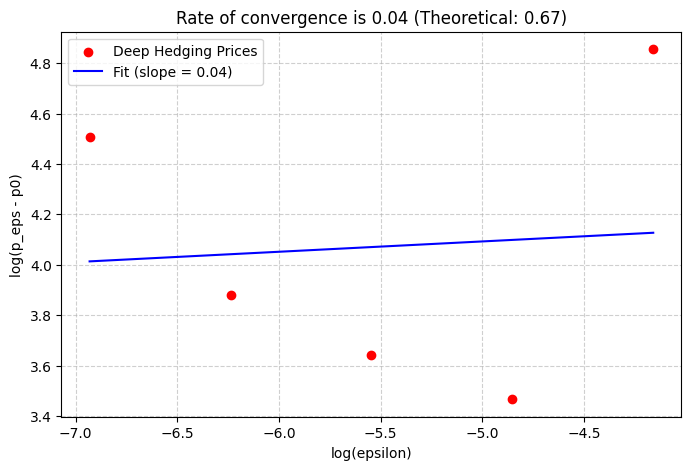

In [ ]:


print("--- Running Transaction Cost Asymptotics O(eps^(2/3)) ---")

# 1. Calculate the frictionless baseline price (p0)
# The paper compares against the theoretical risk-neutral price q[cite: 764].
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
p0 = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# 2. Define the sequence of epsilons
# (Using 2^(-i-5) to match the paper's log-scale axis from roughly -7.0 to -4.5) [cite: 784, 785, 786, 787, 788, 789]
epsilons = [2**(-i-5) for i in range(1, 6)]
price_diffs = []

# 3. Training Loop over epsilons
for eps in epsilons:
    print(f"\nTraining for epsilon = {eps:.5f}...")

    # Train the model with Entropic loss for this specific epsilon
    model_eps, _ = train_model(
        env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
        epsilon=eps, batch_size=batch_size, n_epochs=n_epochs,
        sigma=sigma, loss_type='entropic', lambda_param=1.0
    )

    # Evaluate to get out-of-sample PnL
    with torch.no_grad():
        _, pnl_eps, _ = evaluate_model(
            model_eps, 'bs', test_paths_bs, K, epsilon=eps, S0=S0
        )

    # Calculate the Indifference Price using the stable logsumexp trick
    x = -1.0 * pnl_eps
    p_eps = logsumexp(x) - np.log(len(x))

    price_diffs.append(p_eps - p0)

# 4. Log-Log Regression
log_eps = np.log(epsilons)
log_diffs = np.log(price_diffs)

# Fit a degree-1 polynomial (a line) to extract the slope
slope, intercept = np.polyfit(log_eps, log_diffs, 1)

# 5. Plotting the Asymptotic Convergence
plt.figure(figsize=(8, 5))
plt.scatter(log_eps, log_diffs, color='red', label='Deep Hedging Prices')
plt.plot(log_eps, slope * log_eps + intercept, color='blue', label=f'Fit (slope = {slope:.2f})')

plt.xlabel('log(epsilon)')
plt.ylabel('log(p_eps - p0)')
plt.title(f'Rate of convergence is {slope:.2f} (Theoretical: 0.67)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()